In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle('../data/processed/USDJPY-15m-20210101-20231231_FEATURES.pkl')

In [3]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'spread', 'tick',
       'log_volume', 'o_c_diff', 'o_h_diff', 'o_l_diff', 'close_pct_return',
       'close_return', 'close_log_return', 'close_fd_return',
       'close_log_fd_return', 'EMA_5', 'EMA_5_slope', 'close_to_ema_5',
       'EMA_9', 'EMA_9_slope', 'close_to_ema_9', 'EMA_20', 'EMA_20_slope',
       'close_to_ema_20', 'EMA_24', 'EMA_24_slope', 'close_to_ema_24',
       'EMA_36', 'EMA_36_slope', 'close_to_ema_36', 'EMA_50', 'EMA_50_slope',
       'close_to_ema_50', 'EMA_100', 'EMA_100_slope', 'close_to_ema_100',
       'ATRr_14', 'ATRr_60', 'ATRr_120', 'ADX_14', 'ADXR_14_2', 'DMP_14',
       'DMN_14', 'RSI_14', 'RSI_25', 'RSI_50', 'BBL_5_2.0_2.0',
       'BBM_5_2.0_2.0', 'BBU_5_2.0_2.0', 'BBB_5_2.0_2.0', 'BBP_5_2.0_2.0',
       'BBL_10_2.0_2.0', 'BBM_10_2.0_2.0', 'BBU_10_2.0_2.0', 'BBB_10_2.0_2.0',
       'BBP_10_2.0_2.0', 'BBL_15_2.0_2.0', 'BBM_15_2.0_2.0', 'BBU_15_2.0_2.0',
       'BBB_15_2.0_2.0', 'BBP_15_2.0_2.0', 'BBL_20_2.

In [4]:
import seaborn as sns
from matplotlib import pyplot as plt

In [13]:
print(df["close_log_return"].describe())

count    73884.000000
mean         0.000004
std          0.000603
min         -0.028738
25%         -0.000218
50%          0.000009
75%          0.000237
max          0.014360
Name: close_log_return, dtype: float64


In [5]:
co_mtx = df.corr()
# Print correlation matrix
print(co_mtx)

               open      high       low     close    volume    spread  \
open       1.000000  0.999992  0.999989  0.999985  0.485492  0.208511   
high       0.999992  1.000000  0.999982  0.999991  0.486972  0.208456   
low        0.999989  0.999982  1.000000  0.999992  0.483699  0.208538   
close      0.999985  0.999991  0.999992  1.000000  0.485284  0.208480   
volume     0.485492  0.486972  0.483699  0.485284  1.000000 -0.006859   
...             ...       ...       ...       ...       ...       ...   
dow_cos   -0.001527 -0.001711 -0.001303 -0.001489 -0.075346  0.073451   
dom_sin    0.005224  0.005210  0.005238  0.005213  0.016772 -0.016824   
dom_cos    0.003548  0.003524  0.003579  0.003547 -0.006379  0.017282   
month_sin -0.364784 -0.364469 -0.365099 -0.364778 -0.028131 -0.045706   
month_cos  0.036236  0.036289  0.036119  0.036190  0.131506  0.039578   

               tick  log_volume  o_c_diff  o_h_diff  ...    minute_sin  \
open       0.438780    0.578268 -0.004484  0.2084

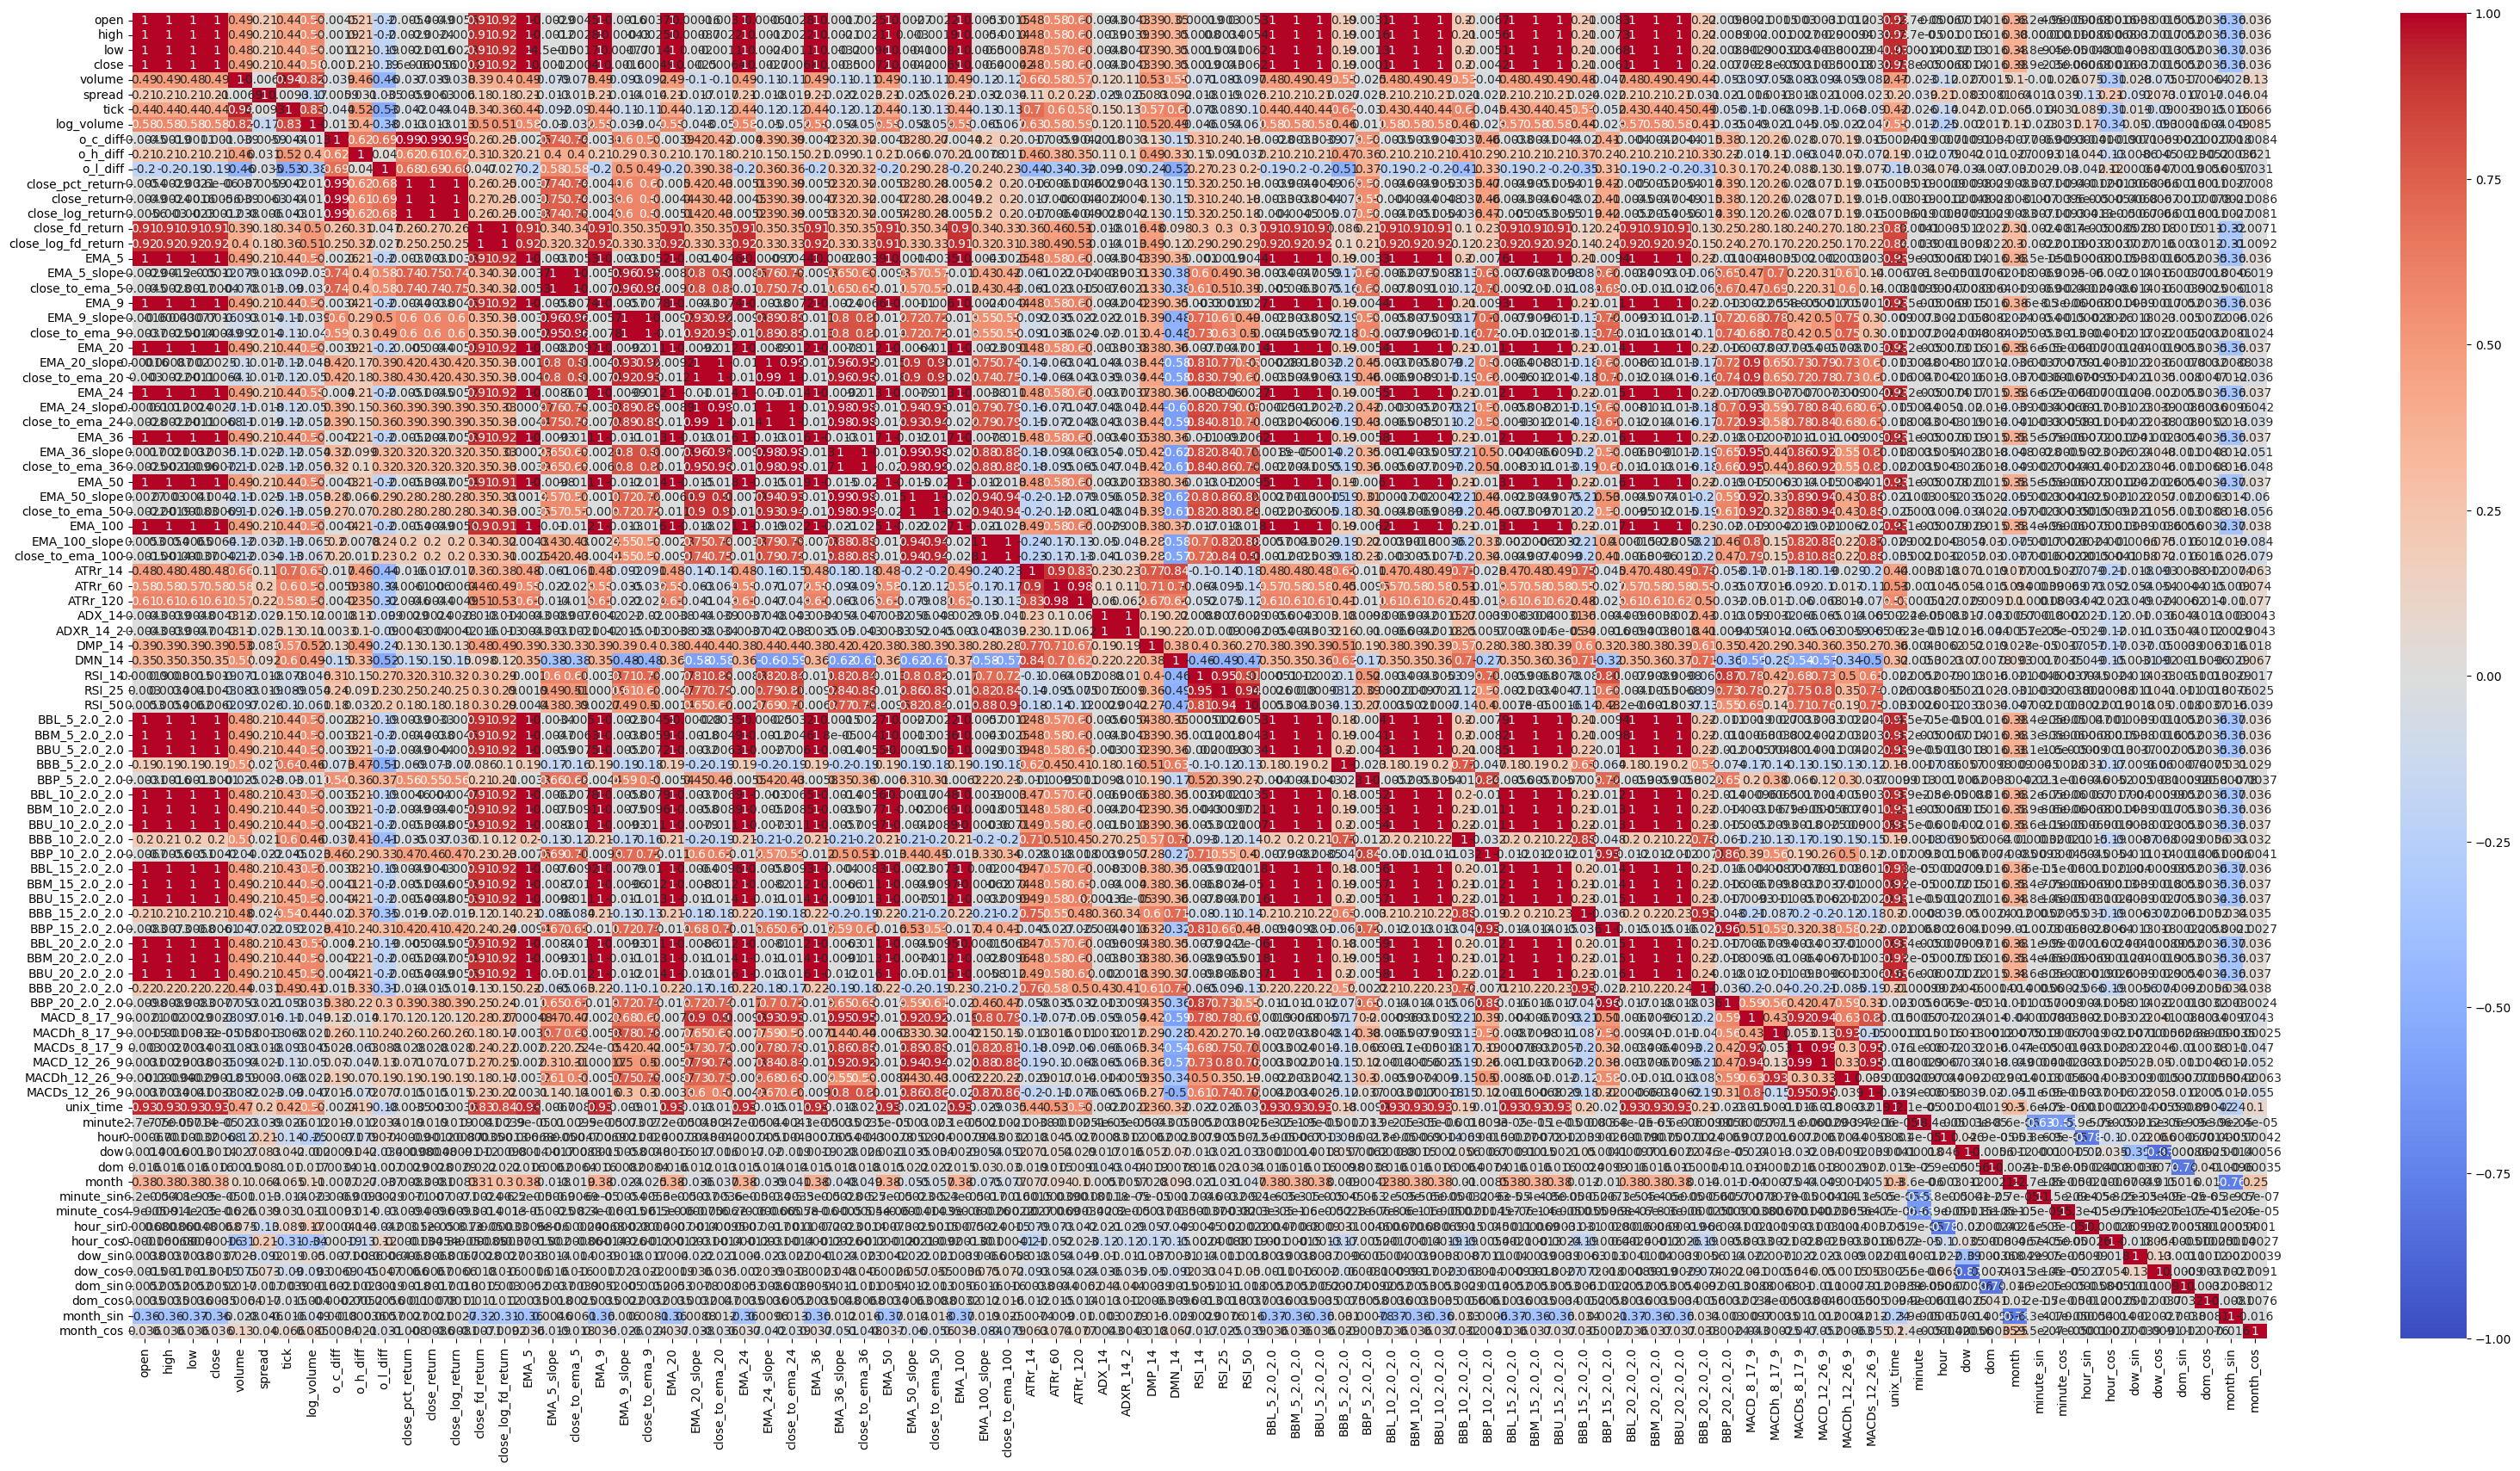

In [6]:
# Plot correlation heatmap
plt.figure(figsize=(40,20))
sns.heatmap(co_mtx, cmap="coolwarm", vmin=-1, vmax=1, annot=True)

# Display heatmap
plt.show()

/var/folders/pj/pm1vc3hj0yd8xdkn1sxryckc0000gn/T/ipykernel_86828/3660315428.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


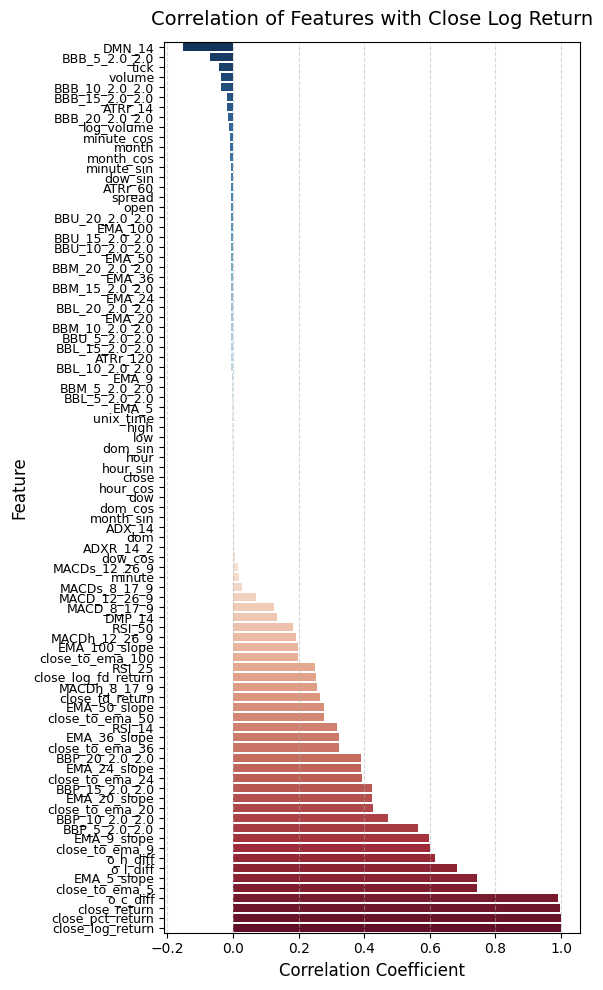

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 計算與 close 的相關係數
corr = df.corr(numeric_only=True)["close_log_return"].sort_values(ascending=True)

plt.figure(figsize=(6, 10))  # 調整圖形比例：窄寬、長高
sns.barplot(
    x=corr.values,
    y=corr.index,
    palette="RdBu_r",
)

# 美化標題與刻度
plt.title("Correlation of Features with Close Log Return", fontsize=14, pad=12)
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)

# 加上網格與邊距
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
